In [1]:
# Core data manipulation and numerical computing
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning -- preprocessing & model selection
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

# Machine Learning -- classifiers
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

# Imbalanced-learn -- resampling
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Evaluation metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score,
    precision_recall_fscore_support, balanced_accuracy_score
)

# Clustering (used in V-feature engineering)
from sklearn.cluster import KMeans

# Global settings
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries loaded successfully.')
print(f'Random seed: {RANDOM_STATE}')

All libraries loaded successfully.
Random seed: 42


In [2]:
#Data loading
train_transaction = pd.read_csv('train_transaction.csv')
print(f'Train transaction shape:{train_transaction.shape}')

train_identity = pd.read_csv('train_identity.csv')
print(f'Train identity shape:{train_identity.shape}')

merge_train_df = train_transaction.merge(train_identity, on="TransactionID", how="left")
print(f'Merged dataset shape:{merge_train_df.shape}')



Train transaction shape:(590540, 394)
Train identity shape:(144233, 41)
Merged dataset shape:(590540, 434)


In [3]:
#Initial summary of dataset
fraudCount = merge_train_df['isFraud'].sum()
totalCount = len(merge_train_df)
fraudRate = merge_train_df['isFraud'].mean()

print(f"\nOverview summary of the dataset")
print(f'  Total transactions : {totalCount}')
print(f'  Total features     : {merge_train_df.shape[1]}')
print(f'  Fraud transactions : {fraudCount}')
print(f'  Fraud rate         : {fraudRate:.3%}')


Overview summary of the dataset
  Total transactions : 590540
  Total features     : 434
  Fraud transactions : 20663
  Fraud rate         : 3.499%


Missing value analysis:
Features with missing data > 95%: 9
Feature with mising data between 50% - 94%: 205
Feature with missing data < 50%: 200


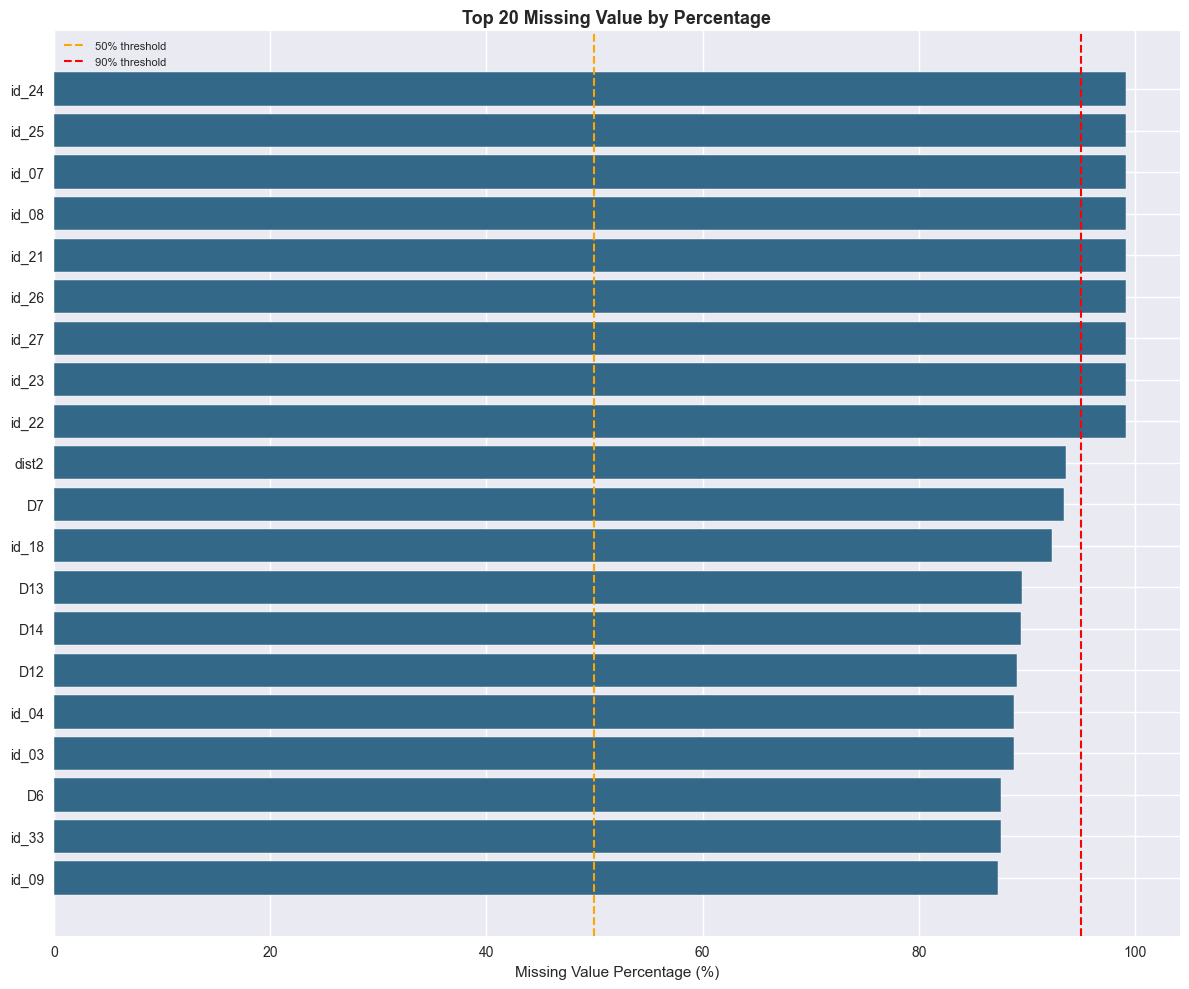

In [4]:
#Exploratory Data Analysis

#Missing Value Profiling
missing_count = merge_train_df.isnull().sum()
missing_percentage = (missing_count/len(merge_train_df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percentage
}).sort_values('Missing Percentage', ascending=False)

print('Missing value analysis:')
print(f'Features with missing data > 95%: {(missing_percentage > 95).sum()}')
print(f'Feature with mising data between 50% - 94%: {((missing_percentage >= 50) & (missing_percentage < 95)).sum()}')
print(f'Feature with missing data < 50%: {((missing_percentage < 50) & (missing_percentage > 0)).sum()}')

# Visualise top  features by missingness
top_missing = missing_df[missing_df['Missing Count'] > 0].head(20)

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(
    top_missing.index[::-1],
    top_missing['Missing Percentage'][::-1],
    color = '#346888',
    edgecolor = 'white'
         )
ax.axvline(
    x=50,
    color = 'orange',
    linestyle = '--',
    linewidth = 1.5,
    label = '50% threshold'
)
ax.axvline(
    x=95,
    color = 'red',
    linestyle = '--',
    linewidth = 1.5,
    label = '90% threshold'
)
ax.set_xlabel('Missing Value Percentage (%)')
ax.set_title('Top 20 Missing Value by Percentage', fontweight='bold', fontsize=13)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('Fig.1 [Top 20 Missing Value by Percentage].png', dpi=150, bbox_inches='tight') #Extract to image
plt.show()


Target Variable Distribution:
Not Fraud: 569877 (96.50%)
Fraud: 20663 (3.50%)
Imbalance Ratio: 27.6 : 1


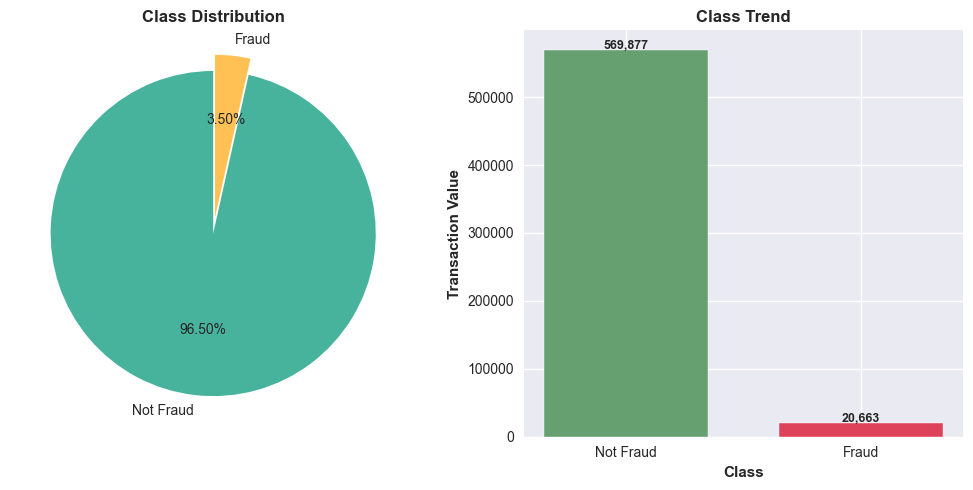

In [5]:
#Fraud & Non-Fraud Distribution

fraud_stats = merge_train_df['isFraud'].value_counts()
imbalance_ratio = fraud_stats[0] / fraud_stats[1]

print('Target Variable Distribution:')
print(f'Not Fraud: {fraud_stats[0]} ({fraud_stats[0]/len(merge_train_df)*100:.2f}%)')
print(f'Fraud: {fraud_stats[1]} ({fraud_stats[1]/len(merge_train_df)*100:.2f}%)')
print(f'Imbalance Ratio: {imbalance_ratio:.1f} : 1')

fig, axes = plt.subplots(1,2, figsize=(10, 5))

axes[0].pie(
    fraud_stats.values,
    labels=['Not Fraud', 'Fraud'],
    autopct = '%1.2f%%',
    startangle = 90,    
    colors = ['#47B39C', '#FFC154'],
    explode = (0, 0.1),
)
axes[0].set_title('Class Distribution', fontweight = 'bold')

axes[1].bar(
    ['Not Fraud', 'Fraud'],
    fraud_stats.values,
    color = ['#66a070', '#de425b'],
    edgecolor = 'white',
    width = 0.7
)
axes[1].set_title('Class Trend', fontweight = 'bold')
axes[1].set_ylabel('Transaction Value', fontweight = 'bold')
axes[1].set_xlabel('Class', fontweight = 'bold')

for i, v in enumerate(fraud_stats.values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontsize=9, fontweight = 'bold')

plt.tight_layout()
plt.savefig('Fig 2 [Class Distribution]', dpi=150, bbox_inches = 'tight')
plt.show()


Statistic of Transaction Amount by Fraud Label:
isFraud           0          1
count   569877.0000 20663.0000
mean       134.5100   149.2400
std        239.4000   232.2100
min          0.2500     0.2900
25%         43.9700    35.0400
50%         68.5000    75.0000
75%        120.0000   161.0000
max      31937.3900  5191.0000


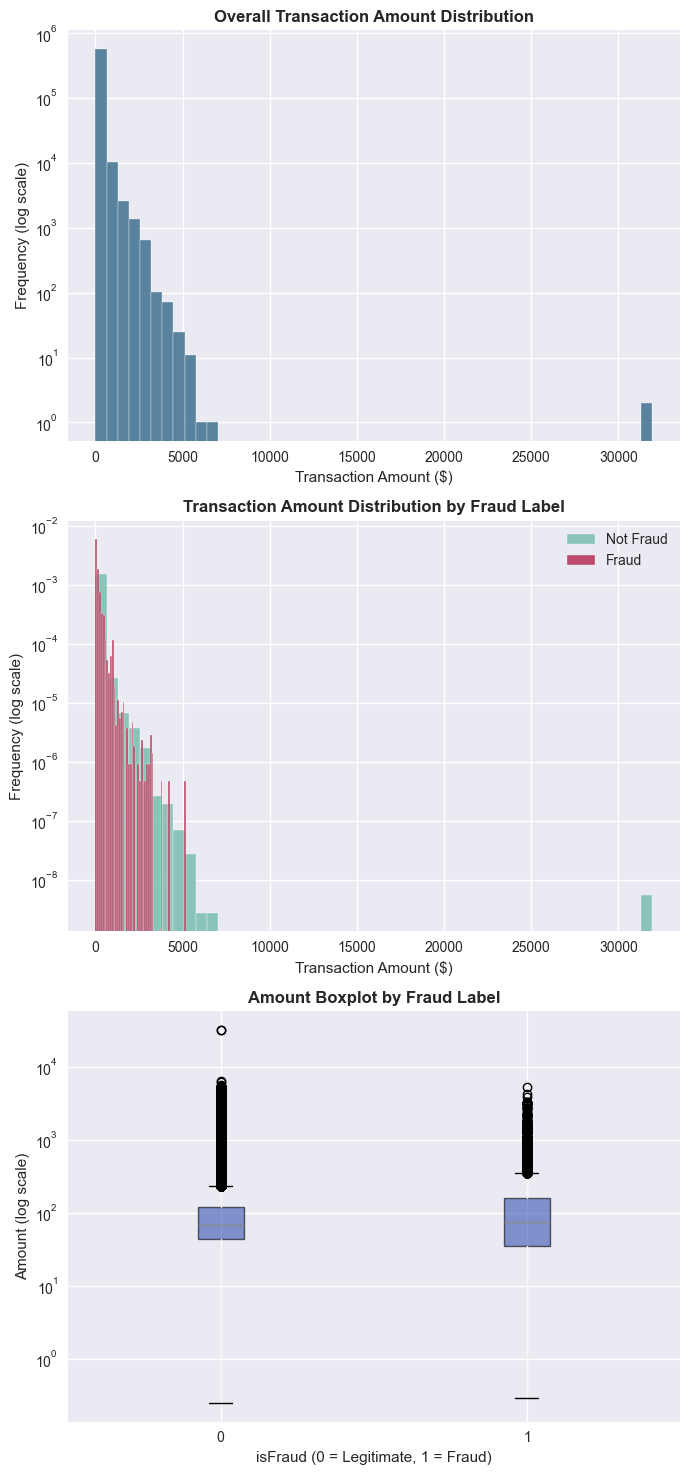

In [21]:
#Transaction Amount Analysis
amount_stats = merge_train_df.groupby('isFraud')['TransactionAmt'].describe().round(2)
print('Statistic of Transaction Amount by Fraud Label:')
print(amount_stats.T)

fig, axes = plt.subplots(3,1, figsize=(7, 15))

axes[0].hist(merge_train_df['TransactionAmt'], bins=50, color='#346888', edgecolor='white', alpha=0.8 )
axes[0].set_yscale('log')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Overall Transaction Amount Distribution', fontweight='bold')

fraud_amounts = merge_train_df[merge_train_df['isFraud'] == 1]['TransactionAmt']
normal_amounts = merge_train_df[merge_train_df['isFraud'] == 0]['TransactionAmt']
axes[1].hist(normal_amounts, bins = 50, color='#72BAA9', edgecolor='white', alpha=0.8, label='Not Fraud', density=True)
axes[1].hist(fraud_amounts, bins = 50, color='#AE2448', edgecolor='white', alpha=0.8, label='Fraud', density=True)
axes[1].set_yscale('log')
axes[1].set_xlabel('Transaction Amount ($)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Transaction Amount Distribution by Fraud Label', fontweight='bold')
axes[1].legend()

merge_train_df.boxplot(
    column = 'TransactionAmt',
    by ='isFraud',
    ax = axes[2],
    patch_artist =True,
    boxprops = dict(
        facecolor = '#3852B4',
        alpha = 0.6
    )
)
axes[2].set_yscale('log')
axes[2].set_xlabel('isFraud (0 = Legitimate, 1 = Fraud)')
axes[2].set_ylabel('Amount (log scale)')
axes[2].set_title('Amount Boxplot by Fraud Label', fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.savefig('Fig 3 [Transaction Amount Dsitribution].png', dpi=150, bbox_inches='tight')
plt.show()